# 💳 Fraud Detection Using Machine Learning

## Importing Libraries

In [ ]:
# importing the libraries for data manipulation and visualization
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')




 ## Data Collection

In [ ]:
# Load the dataset
df=pd.read_csv('/Users/abhinandankumar/data science projects/froad_detection/AIML Dataset.csv')
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


 ##4. Data Overview

In [ ]:
# dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [ ]:
# dataset columns
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [ ]:
# Overall fraud distribution
df['isFraud'].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

## Data Preprocessing

In [ ]:
# Check for missing values
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [7]:
df['isFlaggedFraud'].value_counts()

isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64

In [ ]:
# fraud percentage
fraud_percentage = round(df['isFraud'].value_counts()[1]/len(df)*100, 2)

In [9]:
print(fraud_percentage)

0.13


## Exploratory Data Analysis 

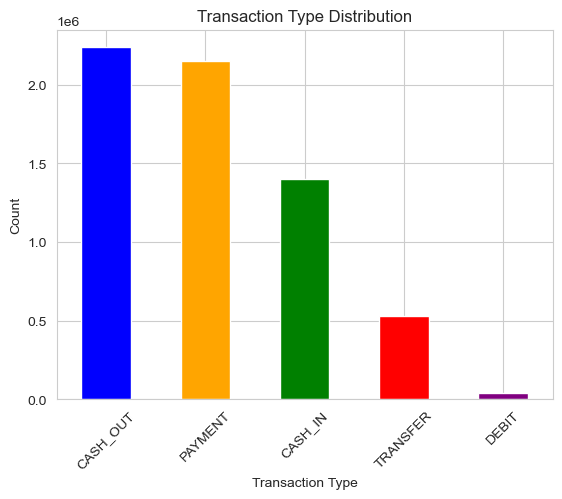

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

In [ ]:
# Transaction type distribution

df["type"].value_counts().plot(kind='bar' , color=['blue', 'orange', 'green', 'red', 'purple', 'brown'])
plt.title('Transaction Type Distribution')
plt.xticks(rotation=45)
plt.xlabel('Transaction Type')
plt.ylabel('Count')
plt.show()
plt.figure(figsize=(10, 6))


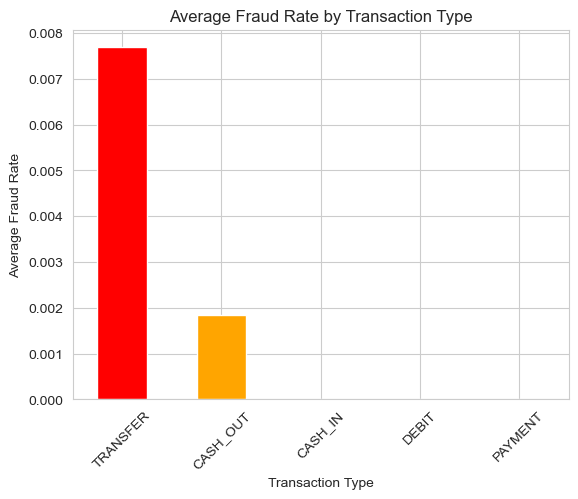

In [ ]:
# Average fraud rate by transaction type

fraud_by_type = df.groupby('type')['isFraud'].mean().sort_values(ascending=False)
fraud_by_type.plot(kind='bar', color=['red', 'orange', 'green', 'blue', 'purple', 'brown'])
plt.title('Average Fraud Rate by Transaction Type')
plt.xlabel('Transaction Type')
plt.ylabel('Average Fraud Rate')
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Transaction amount distribution

df["amount"].describe()

count    6.362620e+06
mean     1.798619e+05
std      6.038582e+05
min      0.000000e+00
25%      1.338957e+04
50%      7.487194e+04
75%      2.087215e+05
max      9.244552e+07
Name: amount, dtype: float64

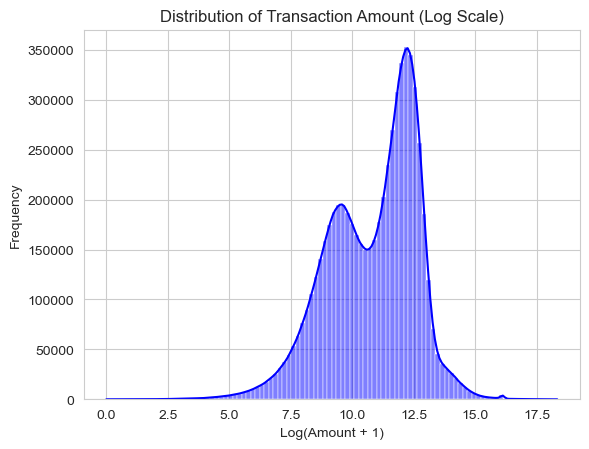

In [ ]:
# Log-transform the amount to handle skewness

sns.histplot(np.log1p(df["amount"]), kde=True ,bins=100 , color='blue')
plt.title('Distribution of Transaction Amount (Log Scale)')
plt.xlabel('Log(Amount + 1)')
plt.ylabel('Frequency')
plt.show()

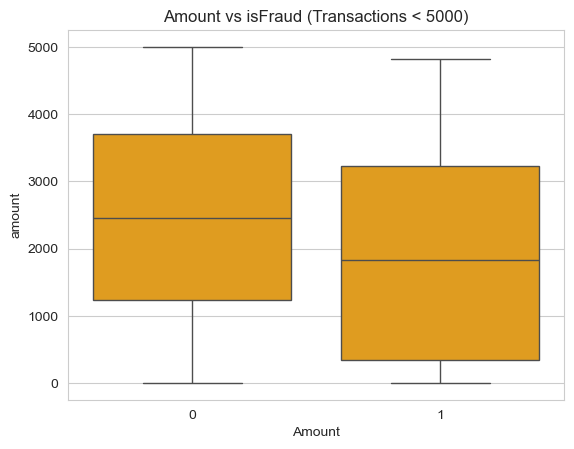

In [ ]:

# Boxplot of amount vs isFraud for transactions less than 5000

sns.boxplot(data=df[df['amount'] <5000], y='amount', x='isFraud', color='orange')
plt.title('Amount vs isFraud (Transactions < 5000)')
plt.xlabel('Amount')
plt.show()

In [ ]:
# checking columns again
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [ ]:
# Create new features for balance differences

df['balanceDiffOrig'] = df['oldbalanceOrg'] - df['newbalanceOrig']
df['balanceDiffDest'] = df['oldbalanceDest'] - df['newbalanceDest']

In [ ]:
# Count how many transactions have a negative balance difference for the origin account
(df['balanceDiffOrig'] < 0).sum()

np.int64(1399253)

In [ ]:

# Count how many transactions have a negative balance difference for the destination account
(df['balanceDiffDest'] < 0).sum()

np.int64(2806464)

In [ ]:
# Display the first few rows of the DataFrame to verify the new features
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiff,balanceDiffDest,balanceDiffOrig
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0,9839.64
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0,1864.28
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,181.00,0.0,181.00
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,181.00,21182.0,181.00
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,11668.14,0.0,11668.14


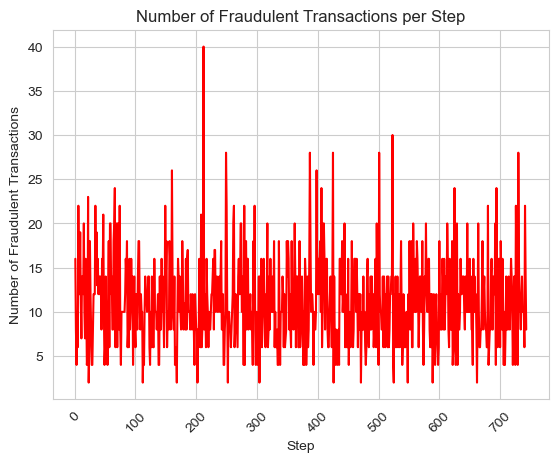

In [ ]:
# Number of fraudulent transactions per step

fraud_per_step = df[df['isFraud'] == 1].groupby('step').size().sort_index()

# Plotting the number of fraudulent transactions per step

plt.plot(fraud_per_step.index, fraud_per_step.values, color='red')
plt.title('Number of Fraudulent Transactions per Step')
plt.xlabel('Step')
plt.ylabel('Number of Fraudulent Transactions')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [ ]:
# Drop the 'step' column as it's no longer needed for analysis
df.drop(columns=['step'], inplace=True)

In [ ]:
# Top 10 senders by number of transactions
top_senders = df['nameOrig'].value_counts().head(10)

In [ ]:

# Top 10 senders by number of transactions
top_senders

nameOrig
C1902386530    3
C363736674     3
C545315117     3
C724452879     3
C1784010646    3
C1677795071    3
C1462946854    3
C1999539787    3
C2098525306    3
C400299098     3
Name: count, dtype: int64

In [ ]:
# Top 10 receivers by number of transactions
top_receivers = df['nameDest'].value_counts().head(10)

In [ ]:
# Top 10 receivers by number of transactions
top_receivers

nameDest
C1286084959    113
C985934102     109
C665576141     105
C2083562754    102
C248609774     101
C1590550415    101
C451111351      99
C1789550256     99
C1360767589     98
C1023714065     97
Name: count, dtype: int64

In [ ]:
# Top 10 senders of fraudulent transactions
fraud_users = df[df['isFraud'] == 1]['nameOrig'].value_counts().head(10)

In [ ]:
# Top 10 senders of fraudulent transactions
fraud_users

nameOrig
C1305486145    1
C755286039     1
C973279667     1
C258213312     1
C1640703547    1
C1127265876    1
C317779855     1
C1064034527    1
C1141104763    1
C1966863341    1
Name: count, dtype: int64

In [ ]:
# Filter transactions of type 'TRANSFER' and 'CASH_OUT' which are more likely to be fraudulent
fraud_types = df[df['type'].isin(['TRANSFER', 'CASH_OUT'])]

In [ ]:
# Filter transactions of type 'TRANSFER' and 'CASH_OUT' which are more likely to be fraudulent
fraud_types.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiff,balanceDiffDest,balanceDiffOrig
2,TRANSFER,181.00,C1305486145,181.0,0.0,C553264065,0.0,0.00,1,0,181.0,0.00,181.0
3,CASH_OUT,181.00,C840083671,181.0,0.0,C38997010,21182.0,0.00,1,0,181.0,21182.00,181.0
15,CASH_OUT,229133.94,C905080434,15325.0,0.0,C476402209,5083.0,51513.44,0,0,15325.0,-46430.44,15325.0
19,TRANSFER,215310.30,C1670993182,705.0,0.0,C1100439041,22425.0,0.00,0,0,705.0,22425.00,705.0
24,TRANSFER,311685.89,C1984094095,10835.0,0.0,C932583850,6267.0,2719172.89,0,0,10835.0,-2712905.89,10835.0


In [ ]:
# Count the number of transactions by type in the filtered dataset
fraud_types['type'].value_counts()

type
CASH_OUT    2237500
TRANSFER     532909
Name: count, dtype: int64

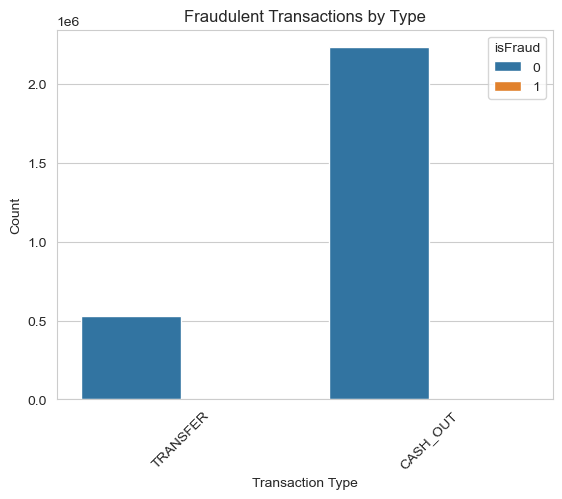

In [ ]:
# Visualize the count of fraudulent transactions by type
sns.countplot(data=fraud_types, x='type', hue='isFraud', )
plt.title('Fraudulent Transactions by Type')
plt.xlabel('Transaction Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Correlation matrix of numerical features
corr=df[['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud']].corr()

In [ ]:
# correlation 
corr

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
amount,1.000000,-0.002762,-0.007861,0.294137,0.459304,0.076688
oldbalanceOrg,-0.002762,1.000000,0.998803,0.066243,0.042029,0.010154
newbalanceOrig,-0.007861,0.998803,1.000000,0.067812,0.041837,-0.008148
oldbalanceDest,0.294137,0.066243,0.067812,1.000000,0.976569,-0.005885
newbalanceDest,0.459304,0.042029,0.041837,0.976569,1.000000,0.000535
isFraud,0.076688,0.010154,-0.008148,-0.005885,0.000535,1.000000


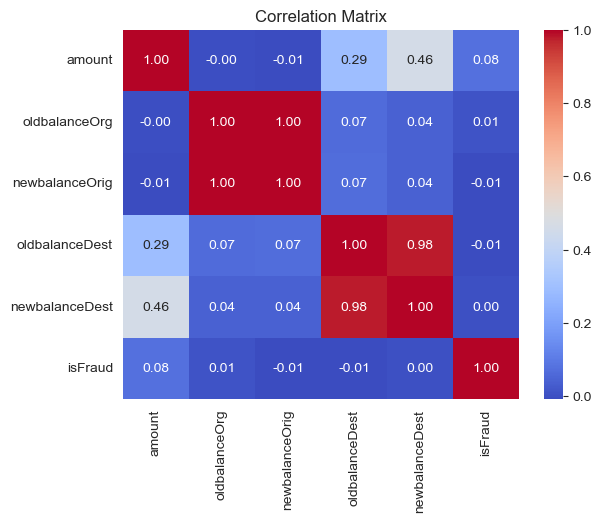

In [ ]:
# Visualize the correlation matrix
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

In [ ]:
# Identify transactions where the origin account balance becomes zero after the transaction, which is a common pattern in fraudulent activities
zero_sfter_transactions = df[
    (df['balanceDiffOrig'] > 0) &
    (df['newbalanceOrig'] == 0) &
    df['type'].isin(['TRANSFER', 'CASH_OUT'])
]


In [ ]:

# Count how many transactions have a zero balance after the transaction
len(zero_sfter_transactions)


1188074

In [ ]:

# Display the first few transactions where the origin account balance becomes zero after the transaction
zero_sfter_transactions.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiff,balanceDiffDest,balanceDiffOrig
2,TRANSFER,181.00,C1305486145,181.0,0.0,C553264065,0.0,0.00,1,0,181.0,0.00,181.0
3,CASH_OUT,181.00,C840083671,181.0,0.0,C38997010,21182.0,0.00,1,0,181.0,21182.00,181.0
15,CASH_OUT,229133.94,C905080434,15325.0,0.0,C476402209,5083.0,51513.44,0,0,15325.0,-46430.44,15325.0
19,TRANSFER,215310.30,C1670993182,705.0,0.0,C1100439041,22425.0,0.00,0,0,705.0,22425.00,705.0
24,TRANSFER,311685.89,C1984094095,10835.0,0.0,C932583850,6267.0,2719172.89,0,0,10835.0,-2712905.89,10835.0


In [ ]:
# Overall fraud distribution
df['isFraud'].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

## Model Training

In [ ]:
# import libraries for modeling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [ ]:
# Display the first few rows of the DataFrame to verify the new features
df.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiff,balanceDiffDest,balanceDiffOrig
0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0,9839.64
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0,1864.28
2,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,181.00,0.0,181.00
3,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,181.00,21182.0,181.00
4,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,11668.14,0.0,11668.14


## Feature Engineering

In [ ]:
# Drop columns that are not needed for modeling
df_model = df.drop(columns=['nameOrig', 'nameDest','isFlaggedFraud'], axis=1)  

In [ ]:
# Define categorical and numerical columns
categorical_cols = ['type']
numerical_cols = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', ]

In [ ]:
# Separate features and target variable
y=df_model['isFraud']
X=df_model.drop(columns=['isFraud'], axis=1)

In [ ]:
# Split the data into training and testing sets
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, stratify=y)

In [ ]:
# Define the preprocessor for numerical and categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first'), categorical_cols)
    ],
    remainder='drop'
)

In [ ]:
# Create a pipeline that combines the preprocessor with a logistic regression model
Pipeline=Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced', max_iter=1000))
])

In [ ]:
# Fit the pipeline on the training data and make predictions on the test set
Pipeline.fit(Xtrain, ytrain)
ypred=Pipeline.predict(Xtest)



### Model Evaluation

In [ ]:

#  accuracy of the model
classification_rep = classification_report(ytest, ypred)
print(classification_rep)

              precision    recall  f1-score   support

           0       1.00      0.94      0.97   1270881
           1       0.02      0.95      0.04      1643

    accuracy                           0.94   1272524
   macro avg       0.51      0.95      0.51   1272524
weighted avg       1.00      0.94      0.97   1272524



In [ ]:
# Display the confusion matrix
confusion_matrix(ytest, ypred)


array([[1200734,   70147],
       [     89,    1554]])

In [ ]:
# Overall accuracy of the model in percentage
Pipeline.score(Xtest, ytest)*100

94.48057561193345

In [ ]:
# Save the trained model using joblib
import joblib
joblib.dump(Pipeline, 'fraud_detection_model.pkl')

['fraud_detection_model.pkl']